In [13]:
import scipy

from src.utils import ingaas_processing
import numpy as np
import matplotlib.pyplot as plt

In [2]:
scan_path = "F://Work//LIPI//scans//scan_20260226_152601.raw"
scan_raw = ingaas_processing.load_raw_image(scan_path, 640, 512)

-32768 32767 (14628, 512, 640) int16


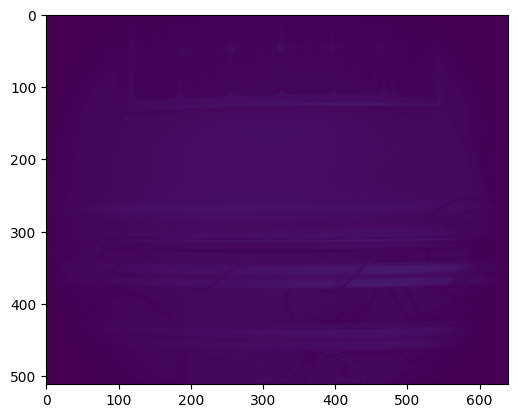

In [3]:
print(np.min(scan_raw), np.max(scan_raw), scan_raw.shape, scan_raw.dtype)
plt.imshow(scan_raw[0])

In [4]:
print(np.min(scan_raw), np.max(scan_raw), scan_raw.shape, scan_raw.dtype)
cal_path = "data/calibration.npz"
K,P,DIM = ingaas_processing.load_calibration(cal_path)
scan_undistort = np.array(ingaas_processing.undistort(scan_raw, K, P, DIM))
#print(np.min(scan_undstrt), np.max(scan_undstrt), scan_undstrt.shape, scan_undstrt.dtype)
#scan_r = np.int16(((scan_undstrt-scan_undstrt.min())//((scan_undstrt.max()-scan_undstrt.min()) - 0.5) * 2**16))
#print(np.min(scan_r), np.max(scan_r), scan_r.shape, scan_r.dtype)

scan = scan_undistort

-32768 32767 (14628, 512, 640) int16


280


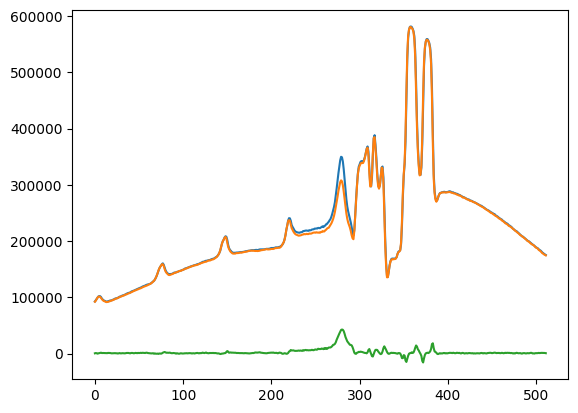

In [5]:
frame_profile = np.sum(scan, axis=2)
plt.plot(frame_profile[4001])
plt.plot(frame_profile[4000])
plt.plot(frame_profile[4001]-frame_profile[4000])
print(np.argmax(frame_profile[4001]-frame_profile[4000]))

6 2078 (14628, 512, 640) int16


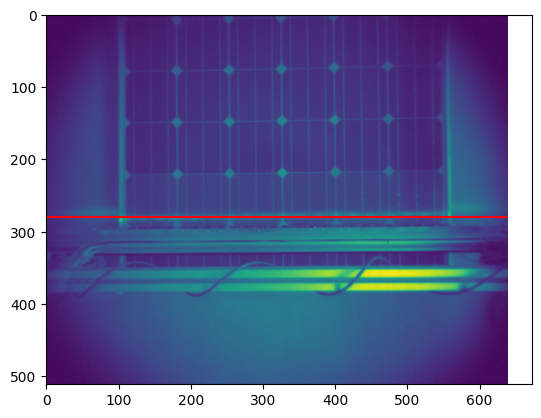

In [6]:
print(np.min(scan), np.max(scan), scan.shape, scan.dtype)
plt.imshow(scan[4002])
plt.hlines(280, 0, 640, "r")

In [7]:
scan_profile = frame_profile[:,280]

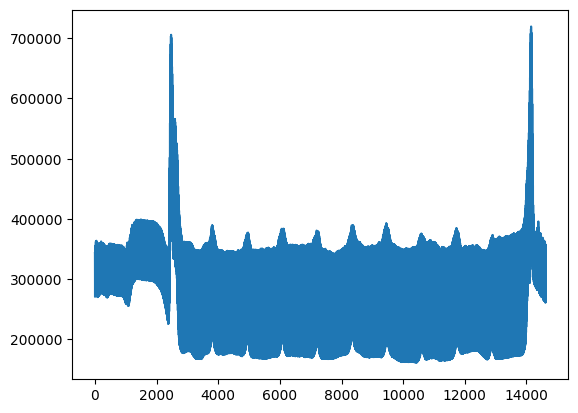

In [8]:
plt.plot(scan_profile)

2472 14151


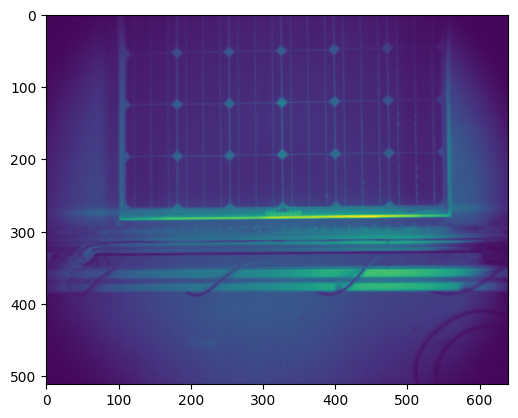

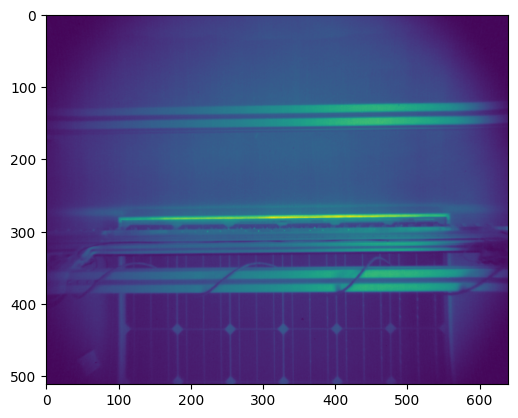

In [139]:
peaks, properties = scipy.signal.find_peaks(scan_profile, prominence=0, wlen=1000)
sorted_index = np.argsort(properties_2["prominences"])
peak_1 = peaks[sorted_index[-1]]
peak_2 = peaks[sorted_index[-2]]
print(peak_1, peak_2)
module_start = min(peak_1, peak_2)
module_end = max(peak_1, peak_2)
plt.imshow(scan[module_start])
plt.show()
plt.imshow(scan[module_end])
plt.show()

In [ ]:
#scipy envelope??
#low pass filter or something to detect the large peaks then remove start and end of module for further analysis of the scan